In [1]:
import numpy as np
import os
from mpi4py import MPI

from astropy.io import fits
from astropy.table import Table
from astropy.table import join
from astropy.table import vstack
from astropy.table import Column

from scipy.spatial import cKDTree
from scipy.optimize import curve_fit

import pypower, Corrfunc
from pypower import CatalogFFTPower, DirectPower
from Corrfunc.mocks.DDsmu_mocks import DDsmu_mocks
from pycorr import TwoPointCorrelationFunction

from astropy.cosmology import FlatLambdaCDM

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')
cmap = sns.color_palette('mako', as_cmap=True)

In [2]:
base = '/pscratch/sd/v/vtorresg/cosmic-web/dr2'

## Correlation function

$$\xi(r)$$

Isotropic (easier): $\xi(r)$ -> Only depends of total separation

Anisotropic: $\xi(r_{\perp}, \; r_{\parallel})$

or multipoles: $\xi_0$, $\xi_2$, $\xi_4$ -> better for RSD

#### All BGS

In [3]:
b = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/PIP/'

In [4]:
real = Table.read(f'{b}/BGS_ANY_clustering.dat.fits')
rand = Table.read(f'{b}/BGS_ANY_0_clustering.ran.fits')
len(real), len(rand)

(11504552, 30945106)

In [5]:
s_edges = np.logspace(np.log10(1.0), np.log10(50.0), 16)
mu_max = 1.0
nmu_bins = 20
nthreads = 8

In [6]:
zmin, zmax = 0.1, 0.4

md = (real['Z'] >= zmin) & (real['Z'] < zmax)
mr = (rand['Z'] >= zmin) & (rand['Z'] < zmax)

real = real[md]
rand = rand[mr]

len(real), len(rand)

(9185876, 24703914)

In [7]:
RA_d = np.asarray(real['RA'], dtype=np.float64)
DEC_d = np.asarray(real['DEC'], dtype=np.float64)
Z_d = np.asarray(real['Z'], dtype=np.float64)
W_d = np.asarray(real['WEIGHT'], dtype=np.float64)

In [8]:
RA_r = np.asarray(rand['RA'], dtype=np.float64)
DEC_r = np.asarray(rand['DEC'], dtype=np.float64)
Z_r = np.asarray(rand['Z'], dtype=np.float64)
W_r = np.asarray(rand['WEIGHT'], dtype=np.float64)

In [9]:
cosmo = FlatLambdaCDM(H0=100.0, Om0=0.315)

In [10]:
chi_d = np.asarray(cosmo.comoving_distance(Z_d).value, dtype=np.float64)
chi_r = np.asarray(cosmo.comoving_distance(Z_r).value, dtype=np.float64)

In [11]:
print('W_d shape =', W_d.shape)
print('matches RA_d?', len(W_d) == len(RA_d))

W_d shape = (9185876,)
matches RA_d? True


In [12]:
print('W_r shape =', W_r.shape)
print('matches RA_r?', len(W_r) == len(RA_r))

W_r shape = (24703914,)
matches RA_r? True


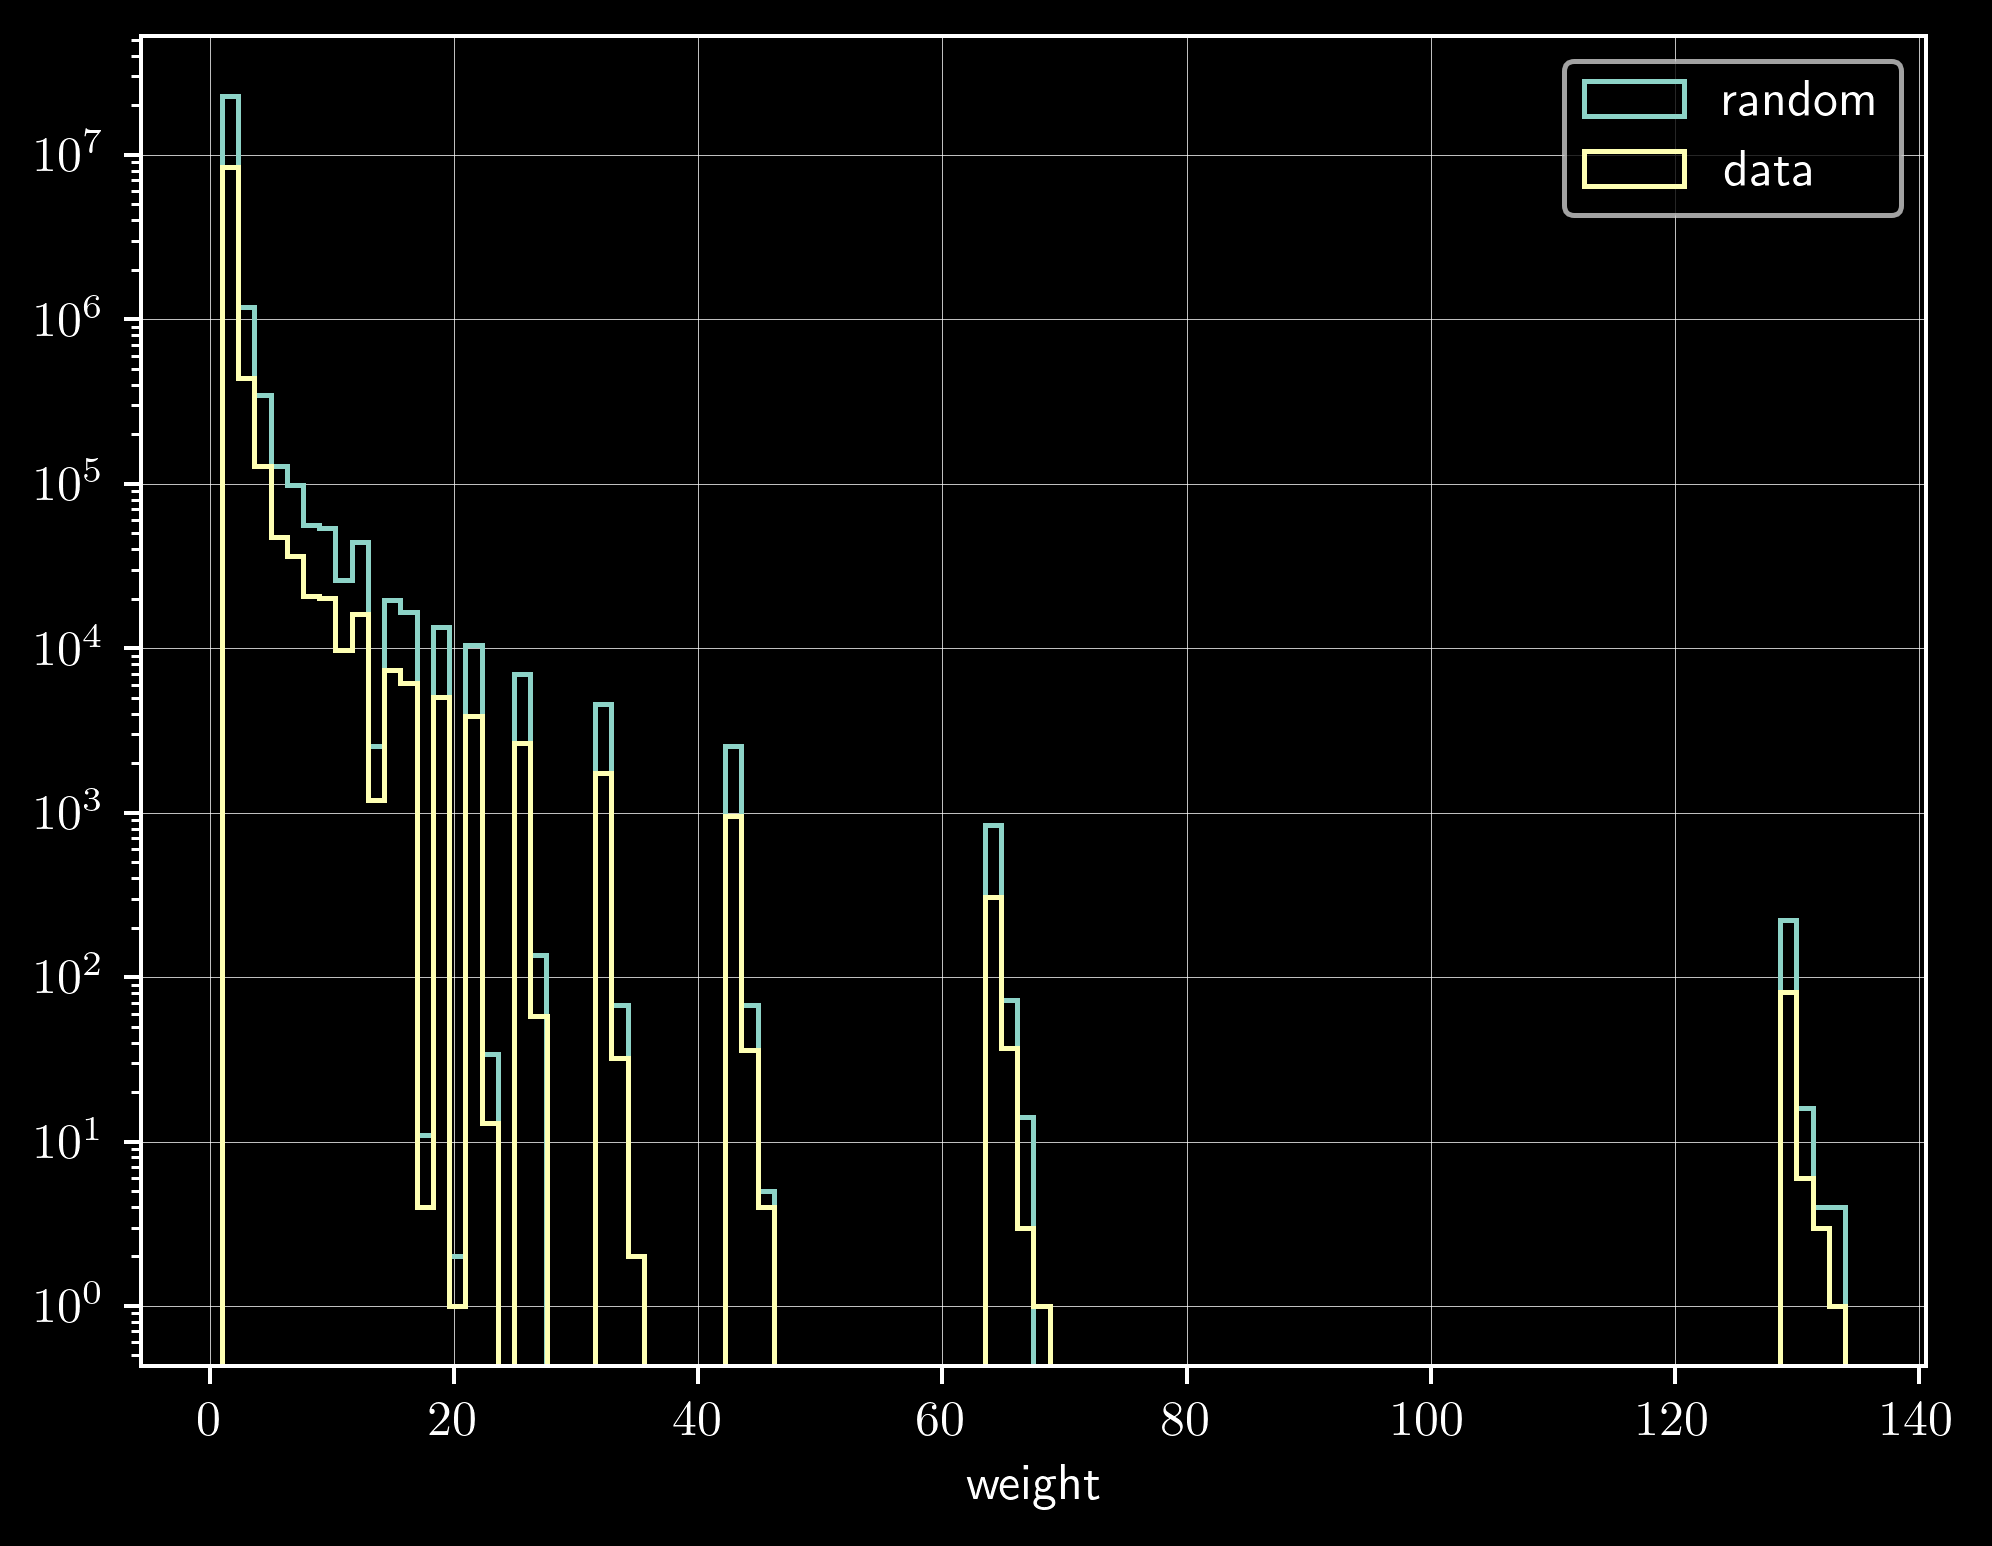

In [13]:
fig, ax = plt.subplots()
ax.grid(lw=0.15)

ax.hist(W_r, bins=100, histtype='step', label='random')
ax.hist(W_d, bins=100, histtype='step', label='data')

ax.set_yscale('log')
ax.legend()
ax.set_xlabel('weight')
plt.show()

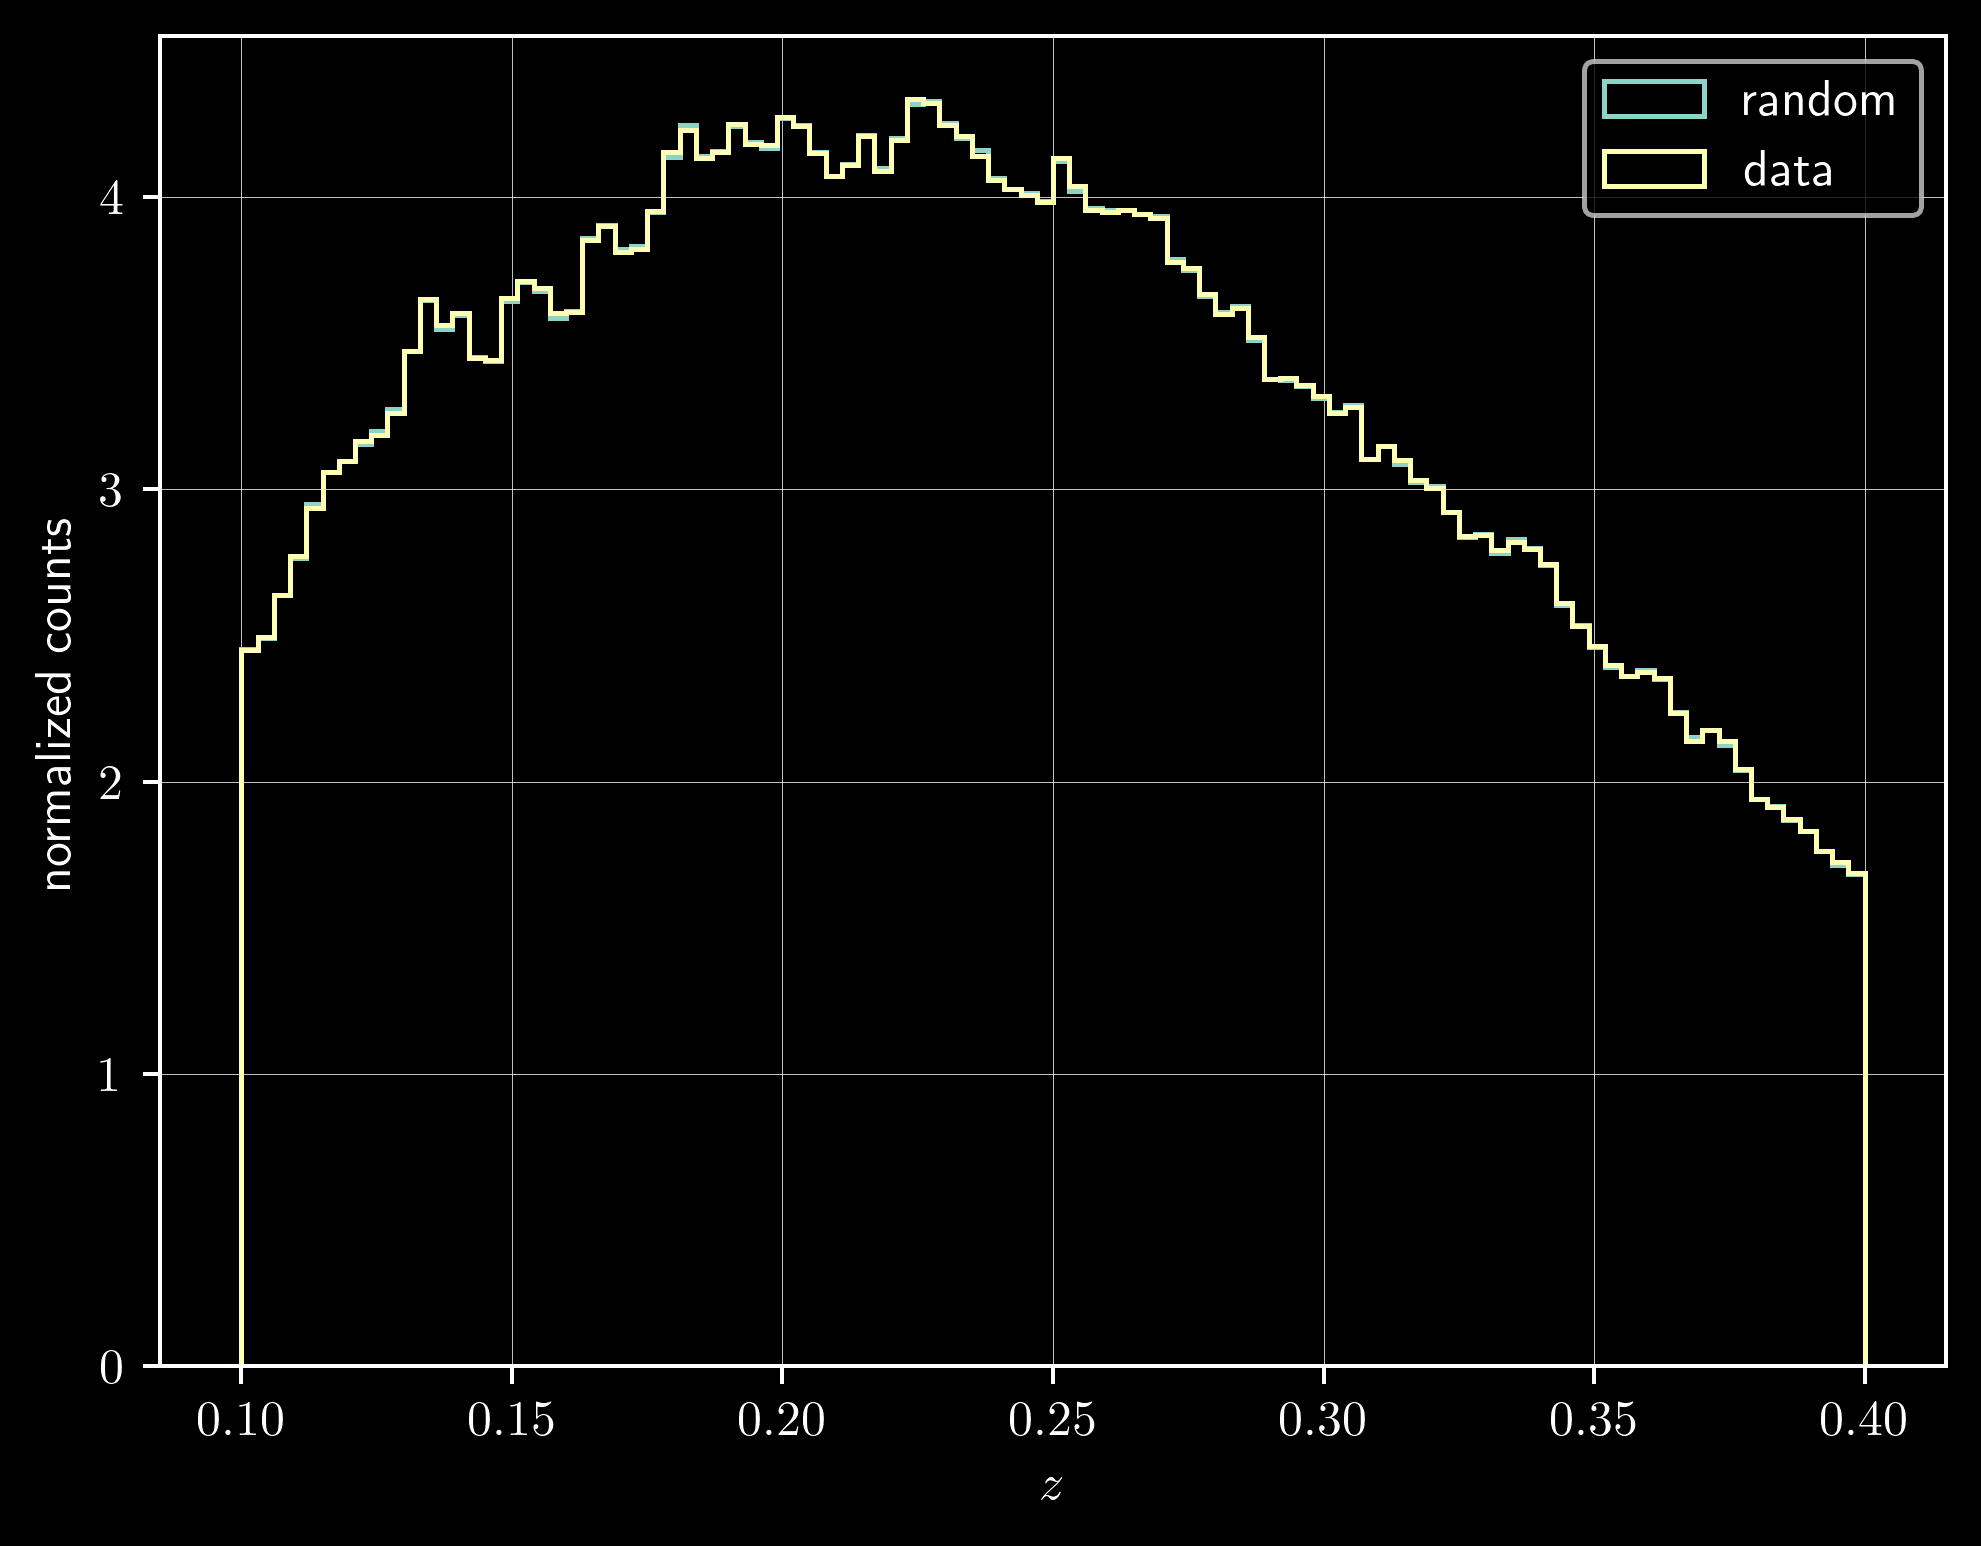

In [14]:
fig, ax = plt.subplots()
ax.grid(lw=0.15)

ax.hist(Z_r, bins=100, density=True, histtype='step', label='random')
ax.hist(Z_d, bins=100, density=True, histtype='step', label='data')

ax.set_xlabel('$z$')
ax.set_ylabel('normalized counts')
ax.legend()
plt.show()

In [15]:
DD = DDsmu_mocks(autocorr=1, cosmology=1,
                 nthreads=nthreads, mu_max=mu_max,
                 nmu_bins=nmu_bins, binfile=s_edges,
                 RA1=RA_d, DEC1=DEC_d, CZ1=chi_d,
                 weights1=W_d, weight_type='pair_product',
                 is_comoving_dist=True)

In [16]:
DR = DDsmu_mocks(autocorr=0, cosmology=1,
                 nthreads=nthreads, mu_max=mu_max,
                 nmu_bins=nmu_bins, binfile=s_edges,
                 RA1=RA_d, DEC1=DEC_d, CZ1=chi_d,
                 RA2=RA_r, DEC2=DEC_r, CZ2=chi_r,
                 weights1=W_d, weights2=W_r,
                 weight_type='pair_product',
                 is_comoving_dist=True)

In [17]:
RR = DDsmu_mocks(autocorr=1, cosmology=1,
                 nthreads=nthreads, mu_max=mu_max,
                 nmu_bins=nmu_bins, binfile=s_edges,
                 RA1=RA_r, DEC1=DEC_r, CZ1=chi_r,
                 weights1=W_r, weight_type="pair_product",
                 is_comoving_dist=True)

Landy–Szalay:

$$\xi(r)=\frac{DD(r)−2DR(r)+RR(r)}{RR(r)}$$

In [18]:
def get_weighted_counts(res):
    npairs = np.asarray(res['npairs'], dtype=np.float64)
    if 'weightavg' in res.dtype.names:
        weightavg = np.asarray(res['weightavg'], dtype=np.float64)
        return npairs * weightavg
    return npairs.copy()

In [19]:
DD_counts = get_weighted_counts(DD)
DR_counts = get_weighted_counts(DR)
RR_counts = get_weighted_counts(RR)

Auto-pairs (excludes self-pairs):
$$\left( \sum_i w_i \right)^2 - \sum_i w_i^2$$

Cross-pairs:
$$\left( \sum_i w_i \right)\left( \sum_j w_j \right)$$

In [20]:
def pair_norm_auto(weights):
    weights = np.asarray(weights, dtype=np.float64)
    return (weights.sum() ** 2) - np.sum(weights ** 2)

def pair_norm_cross(weights1, weights2):
    weights1 = np.asarray(weights1, dtype=np.float64)
    weights2 = np.asarray(weights2, dtype=np.float64)
    return weights1.sum() * weights2.sum()

In [21]:
norm_DD = pair_norm_auto(W_d)
norm_RR = pair_norm_auto(W_r)
norm_DR = pair_norm_cross(W_d, W_r)

In [22]:
DDn = DD_counts / norm_DD
DRn = DR_counts / norm_DR
RRn = RR_counts / norm_RR

In [23]:
xi = np.full_like(RRn, np.nan, dtype=np.float64)
mask = RRn > 0
xi[mask] = (DDn[mask] - 2.0 * DRn[mask] + RRn[mask]) / RRn[mask]

Corrfunc returns everything as a 1D list of bins:

Reshapes it into a 2D array:
- rows = separation bins
- columns = $\mu$ bins

```xi_smu``` = $\xi (s_i, \mu_j)$

In [24]:
ns = len(s_edges) - 1
xi_smu = xi.reshape(ns, nmu_bins)

In [25]:
DDn_2d = DDn.reshape(ns, nmu_bins)
DRn_2d = DRn.reshape(ns, nmu_bins)
RRn_2d = RRn.reshape(ns, nmu_bins)

In [26]:
print('DD_counts shape:', DD_counts.shape)
print('DR_counts shape:', DR_counts.shape)
print('RR_counts shape:', RR_counts.shape)

DD_counts shape: (300,)
DR_counts shape: (300,)
RR_counts shape: (300,)


------------------

Unweighted

In [28]:
DD_u = DDsmu_mocks(autocorr=1, cosmology=1,
                   nthreads=nthreads, mu_max=mu_max,
                   nmu_bins=nmu_bins, binfile=s_edges,
                   RA1=RA_d, DEC1=DEC_d, CZ1=chi_d,
                   is_comoving_dist=True)

In [29]:
DR_u = DDsmu_mocks(autocorr=0, cosmology=1,
                   nthreads=nthreads, mu_max=mu_max,
                   nmu_bins=nmu_bins, binfile=s_edges,
                   RA1=RA_d, DEC1=DEC_d, CZ1=chi_d,
                   RA2=RA_r, DEC2=DEC_r, CZ2=chi_r,
                   is_comoving_dist=True)

In [30]:
RR_u = DDsmu_mocks(autocorr=1, cosmology=1,
                   nthreads=nthreads, mu_max=mu_max,
                   nmu_bins=nmu_bins, binfile=s_edges,
                   RA1=RA_r, DEC1=DEC_r, CZ1=chi_r,
                   is_comoving_dist=True)

In [31]:
DDc_u = np.asarray(DD_u['npairs'], dtype=np.float64)
DRc_u = np.asarray(DR_u['npairs'], dtype=np.float64)
RRc_u = np.asarray(RR_u['npairs'], dtype=np.float64)

In [32]:
ND = len(RA_d)
NR = len(RA_r)

In [33]:
norm_DD_u = ND * (ND - 1)
norm_DR_u = ND * NR
norm_RR_u = NR * (NR - 1)

In [34]:
DDn_u = DDc_u / norm_DD_u
DRn_u = DRc_u / norm_DR_u
RRn_u = RRc_u / norm_RR_u

In [35]:
xi_u = np.full_like(RRn_u, np.nan, dtype=np.float64)
mask = RRn_u > 0
xi_u[mask] = (DDn_u[mask] - 2.0 * DRn_u[mask] + RRn_u[mask]) / RRn_u[mask]

In [36]:
xi_smu_u = xi_u.reshape(ns, nmu_bins)

In [37]:
print('DDc_u shape:', DDc_u.shape)
print('DRc_u shape:', DRc_u.shape)
print('RRc_u shape:', RRc_u.shape)

DDc_u shape: (300,)
DRc_u shape: (300,)
RRc_u shape: (300,)


--------------

Monopoles:

$$\xi_\ell(s) = \frac{2\ell + 1}{2} \int_{-1}^{1} \xi(s,\mu)\, \mathcal{L}(\mu)\, d\mu$$
Where $\mathcal{L}_\ell(\mu)$ is the Legendre polynomial of order $\ell$

$$\mathcal{L}_0 (\mu) = 0$$
$$\mathcal{L}_2 (\mu) = \frac{1}{2} (3 \mu^2 - 1)$$
$$\mathcal{L}_4 (\mu) = \frac{1}{8} (35 \mu^4 - 30 \mu^2 + 3)$$

Corrfunc gives the upper edge of each $\mu$ bin in the field ```mumax```

So to get the center of each bin, you subtract half the bin width:
$$\mu_{\mathrm{center}} = \mu_{\mathrm{max}} - \frac{\Delta \mu}{2}$$

To compute multipoles, you need to evaluate Legendre polynomials at the correct $\mu$ value of each bin

In [38]:
mu_max_arr = np.asarray(DD_u['mumax'], dtype=np.float64)
mu_max_2d = mu_max_arr.reshape(ns, nmu_bins)

In [39]:
dmu = mu_max / nmu_bins
mu_centers_2d = mu_max_2d - 0.5 * dmu

Corrfunc -> bins in range $\mu \in [0,1]$ -> use symmetry in z-space:
$$\xi_\ell (s) = (2\ell + 1) \int_0^1 \xi (s,\mu) \, \mathcal{L}_\ell (\mu) \, d\mu$$
For $\ell = 0,2,4$

Used to project $\xi (s,\mu)$ into multipoles:
- Monopole: $\xi_0$
- Quadrupole: $\xi_2$
- Hexadecapole: $\xi_4$

In [40]:
L0 = np.ones_like(mu_centers_2d)
L2 = 0.5 * (3.0 * mu_centers_2d**2 - 1.0)
L4 = (1.0 / 8.0) * (35.0 * mu_centers_2d**4 - 30.0 * mu_centers_2d**2 + 3.0)

- for $\ell=0$: factor = 1
- for $\ell=2$: factor = 5
- for $\ell=4$: factor = 9

```np.mean``` -> $\mu$ bins are uniform over $[0,1]$, so the integral is approximated by the average over bins

In [41]:
xi0 = np.mean(xi_smu_u * L0, axis=1)
xi2 = 5.0 * np.mean(xi_smu_u * L2, axis=1)
xi4 = 9.0 * np.mean(xi_smu_u * L4, axis=1)

Computes the center of each $s$ bin.

If a bin goes from:
- $s_{min}$
- $s_{max}$

The center is:
$$s_{\mathrm{center}} = \frac{s_{\mathrm{min}}+s_{\mathrm{max}}}{2}$$

In [42]:
s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])

-----

Plots

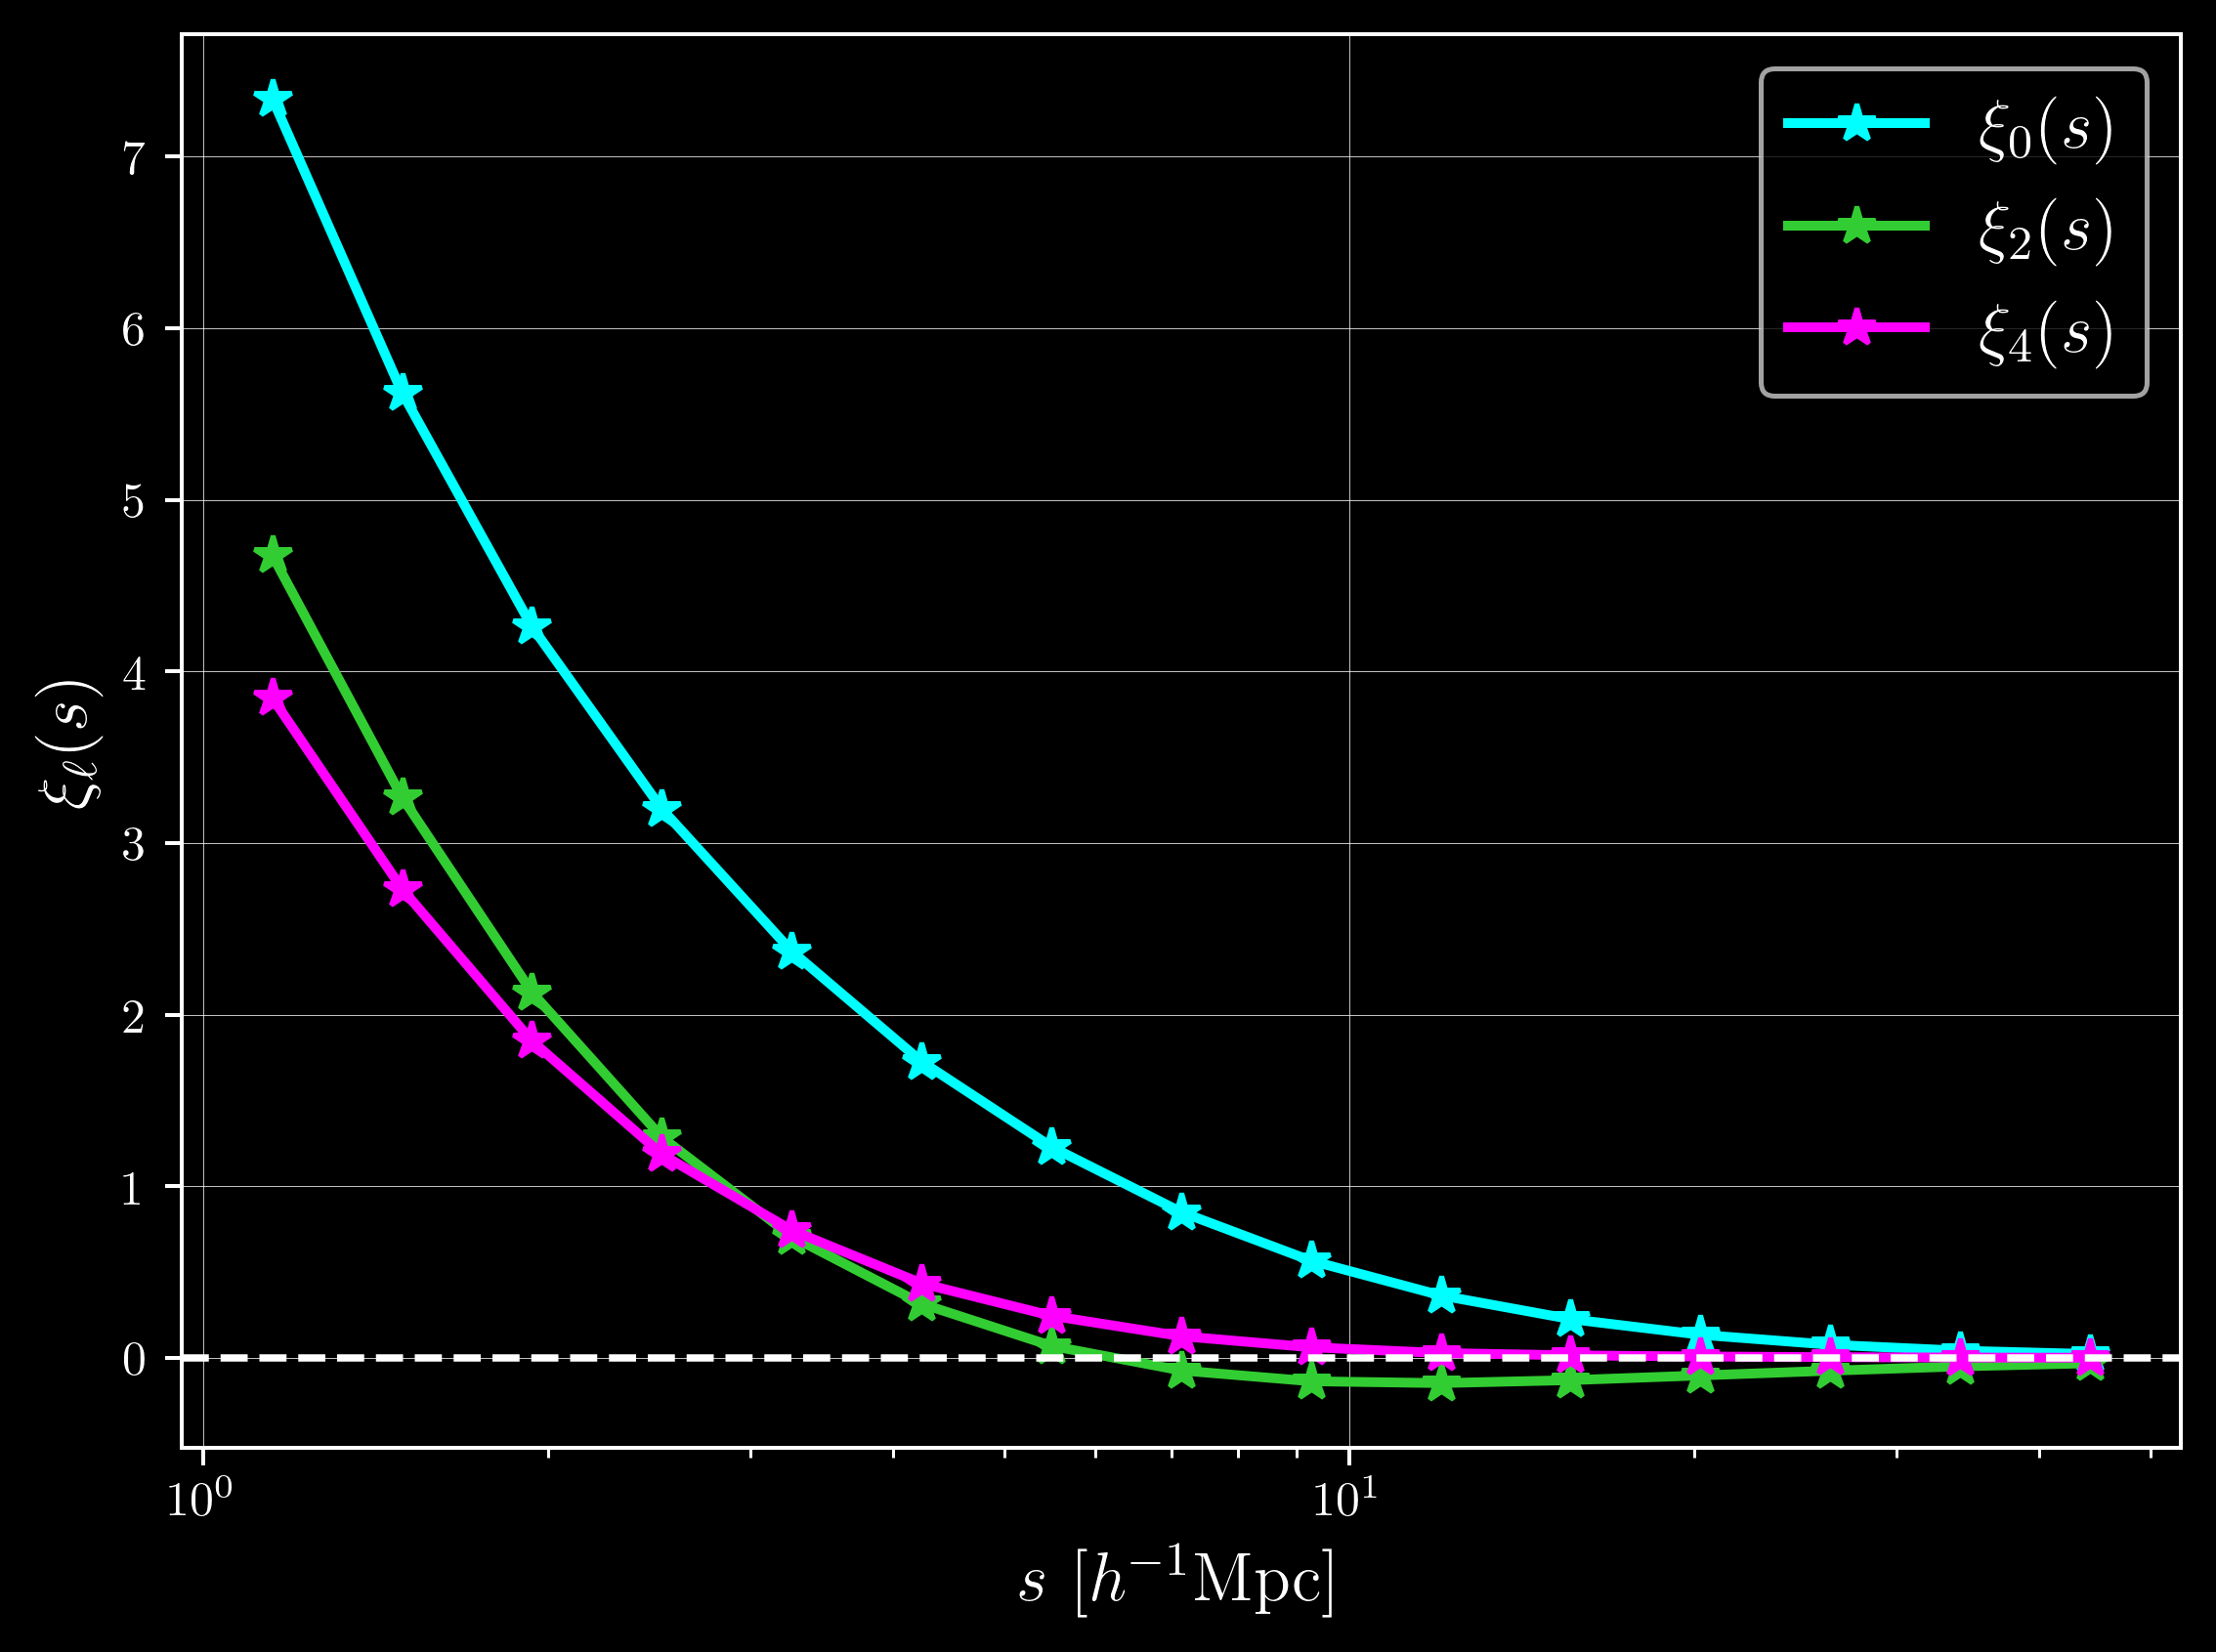

In [49]:
fig, ax = plt.subplots()
ax.grid(lw=0.15)

ax.plot(s_centers, xi0, marker='*', ms=8, color='cyan', lw=2, label=r'$\xi_0(s)$')
ax.plot(s_centers, xi2, marker='*', ms=8, color='limegreen', lw=2, label=r'$\xi_2(s)$')
ax.plot(s_centers, xi4, marker='*', ms=8, color='magenta', lw=2, label=r'$\xi_4(s)$')

ax.set_xscale('log')
ax.axhline(0.0, ls='--', color='white')

ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\xi_\ell(s)$', fontsize=14)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [50]:
xi0_w = np.mean(xi_smu, axis=1)
xi0_u = np.mean(xi_smu_u, axis=1)

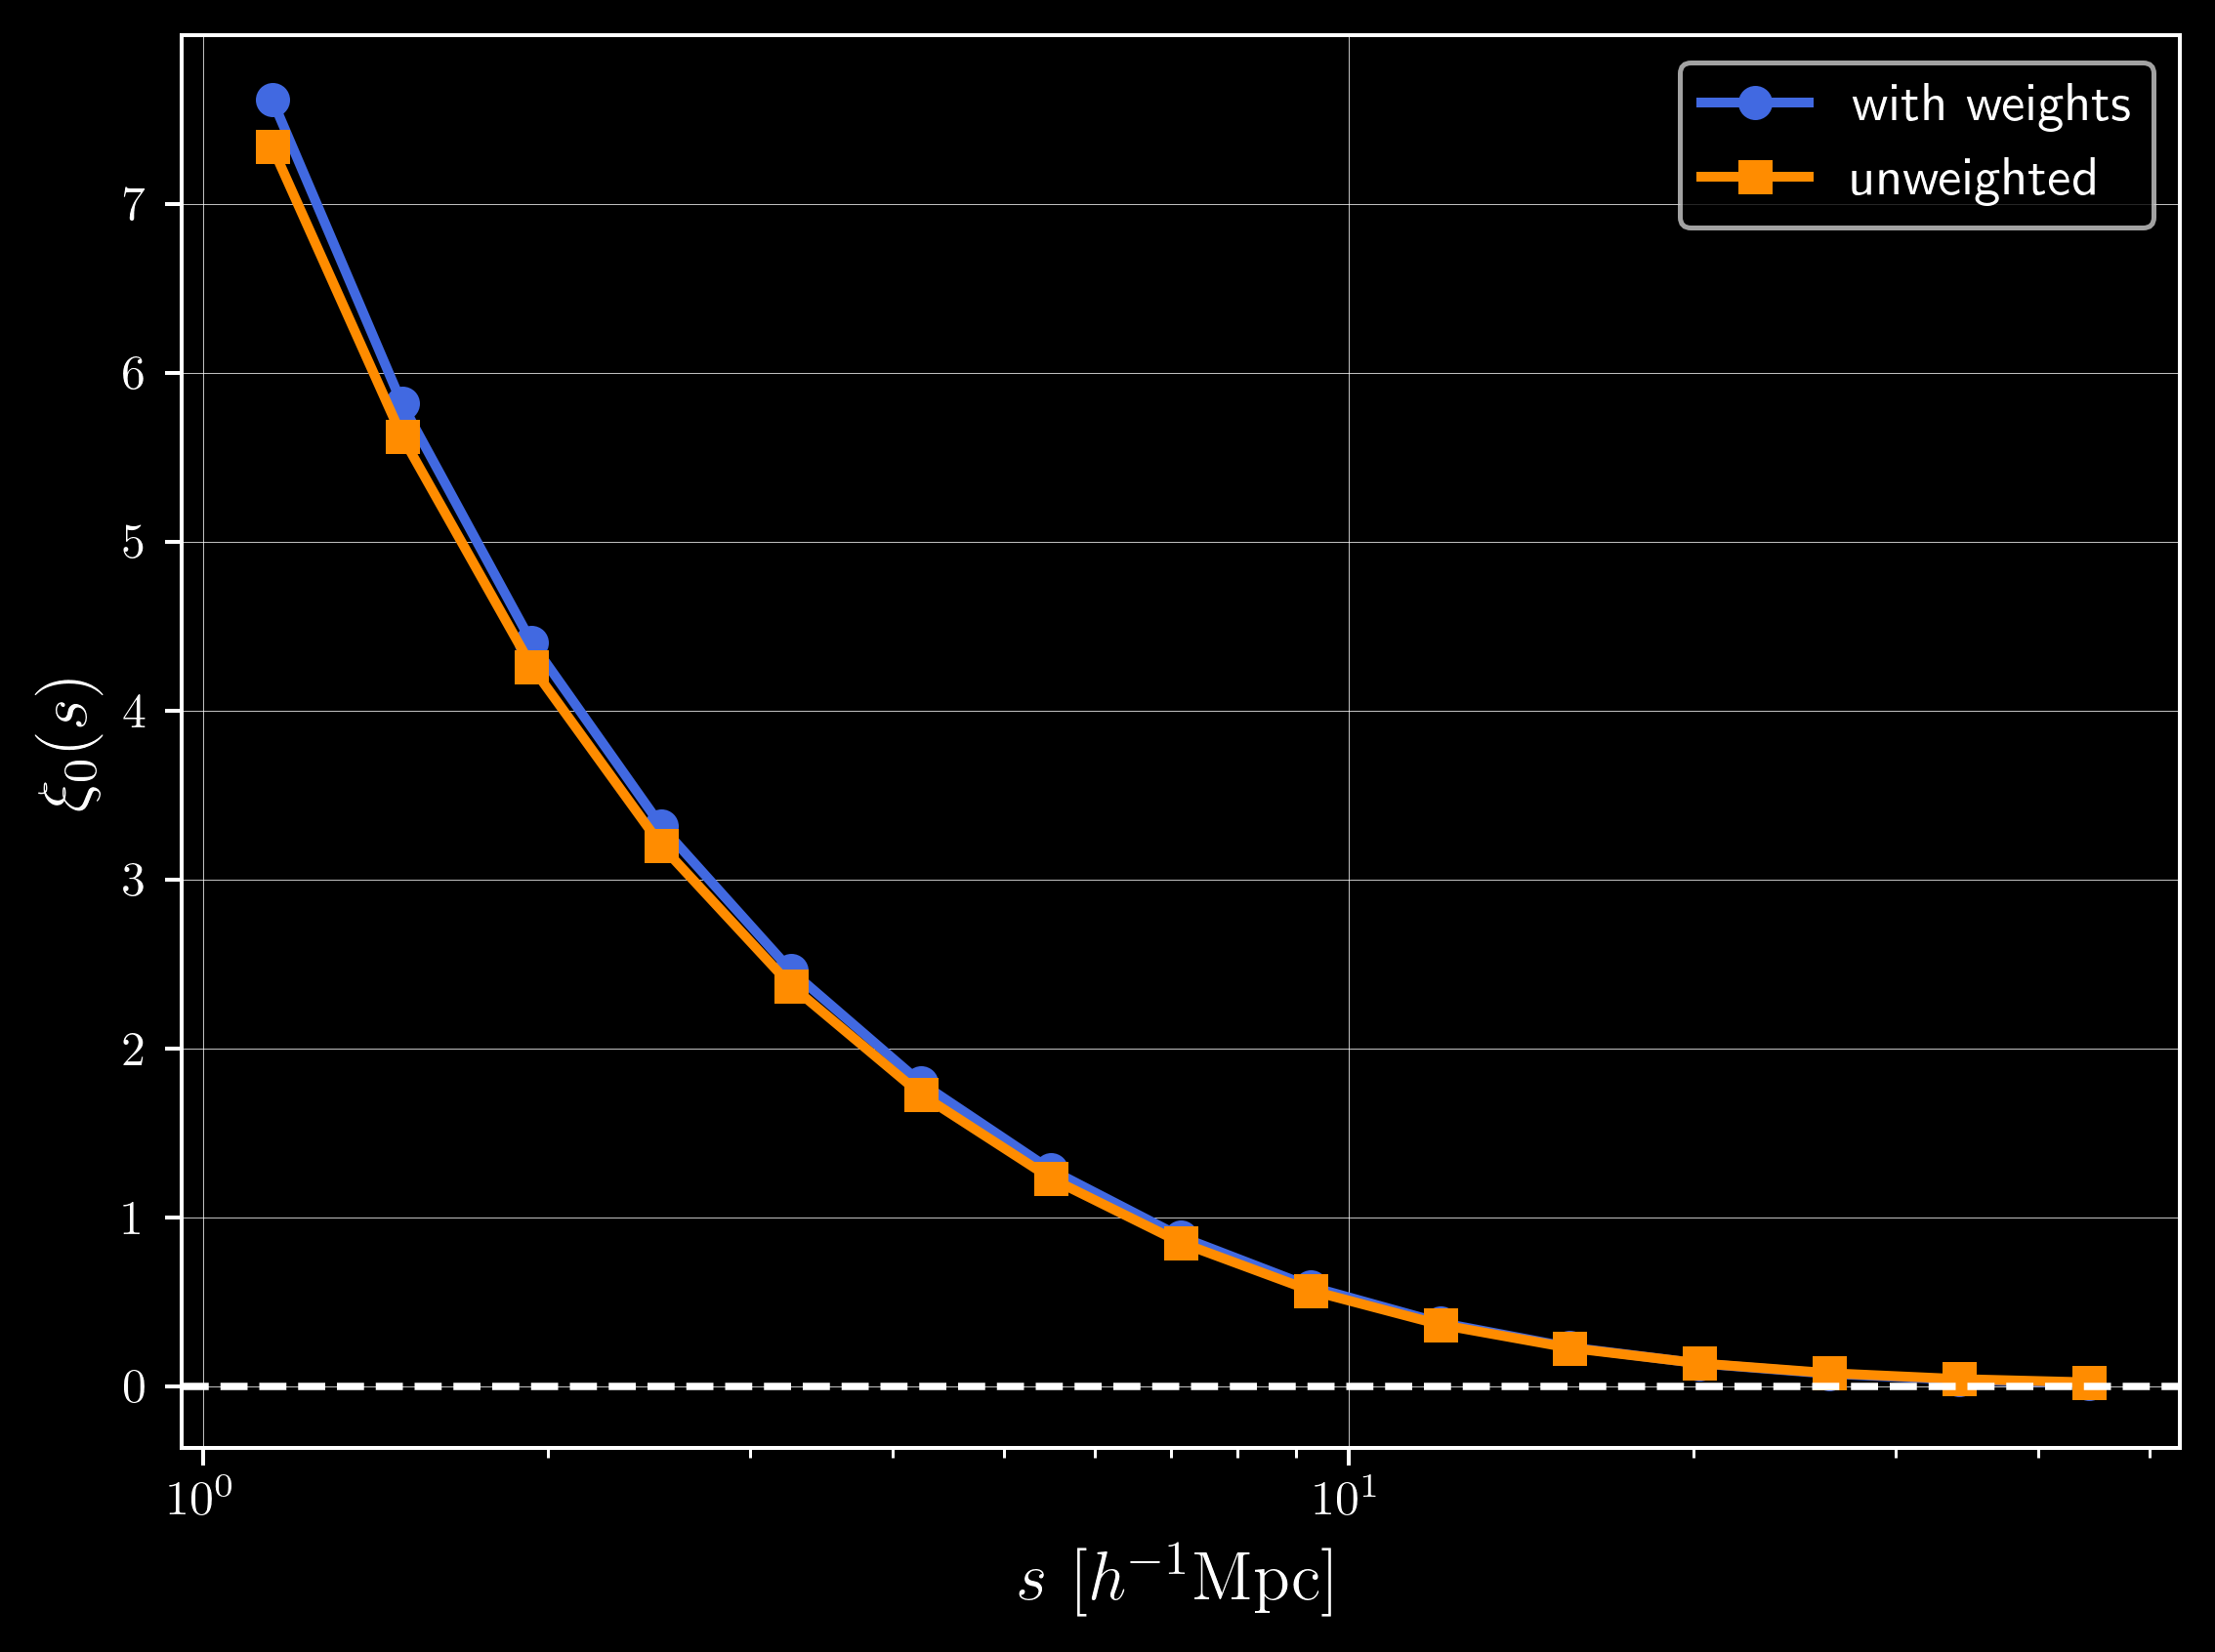

In [54]:
fig, ax = plt.subplots()
ax.grid(lw=0.15)

ax.plot(s_centers, xi0_w, marker='o', color='royalblue', lw=2, label='with weights')
ax.plot(s_centers, xi0_u, marker='s', color='darkorange', lw=2, label='unweighted')

ax.set_xscale('log')
ax.axhline(0.0, ls='--', color='white')

ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\xi_0(s)$', fontsize=14)

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [58]:
print('finite fraction weighted =', np.mean(np.isfinite(xi)))
print('finite fraction unweighted =', np.mean(np.isfinite(xi_u)))

finite fraction weighted = 1.0
finite fraction unweighted = 1.0


In [59]:
print('min/max W_d:', W_d.min(), W_d.max())
print('mean W_d:', W_d.mean(), 'median W_d:', np.median(W_d))

min/max W_d: 1.0 133.92486548423767
mean W_d: 1.4696026894285013 median W_d: 1.023870974779129


In [60]:
print('min/max W_r:', W_r.min(), W_r.max())
print('mean W_r:', W_r.mean(), 'median W_r:', np.median(W_r))

min/max W_r: 0.9974322731020867 133.92486548423767


mean W_r: 1.4666806343841274 median W_r: 1.0226629240306344


## Power spectrum

$$P(k)$$

In [2]:
b = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/PIP/'

real = Table.read(f'{b}/BGS_ANY_clustering.dat.fits')
rand = Table.read(f'{b}/BGS_ANY_0_clustering.ran.fits')

len(real), len(rand)

(11504552, 30945106)

In [3]:
zmin, zmax = 0.1, 0.4

md = (real['Z'] >= zmin) & (real['Z'] < zmax)
mr = (rand['Z'] >= zmin) & (rand['Z'] < zmax)

real = real[md]
rand = rand[mr]

len(real), len(rand)

(9185876, 24703914)

In [4]:
RA_d = np.asarray(real['RA'], dtype=np.float64)
DEC_d = np.asarray(real['DEC'], dtype=np.float64)
Z_d = np.asarray(real['Z'], dtype=np.float64)
W_d = np.asarray(real['WEIGHT'], dtype=np.float64)

RA_r = np.asarray(rand['RA'], dtype=np.float64)
DEC_r = np.asarray(rand['DEC'], dtype=np.float64)
Z_r = np.asarray(rand['Z'], dtype=np.float64)
W_r = np.asarray(rand['WEIGHT'], dtype=np.float64)

In [5]:
cosmo = FlatLambdaCDM(H0=100.0, Om0=0.315)

chi_d = np.asarray(cosmo.comoving_distance(Z_d).value, dtype=np.float64)
chi_r = np.asarray(cosmo.comoving_distance(Z_r).value, dtype=np.float64)

In [6]:
def sky_to_cartesian(ra_deg, dec_deg, dist):
    ra = np.radians(ra_deg)
    dec = np.radians(dec_deg)

    x = dist * np.cos(dec) * np.cos(ra)
    y = dist * np.cos(dec) * np.sin(ra)
    z = dist * np.sin(dec)

    return np.vstack((x, y, z)).T

In [7]:
pos_d = sky_to_cartesian(RA_d, DEC_d, chi_d)
pos_r = sky_to_cartesian(RA_r, DEC_r, chi_r)

print(pos_d.shape, pos_r.shape)

(9185876, 3) (24703914, 3)


In [ ]:
result = CatalogFFTPower(data_positions1=pos_d,
                         randoms_positions1=pos_r,
                         data_weights1=W_d,
                         randoms_weights1=W_r,
                         edges=np.linspace(0.0, 0.4, 81),
                         ells=(0, 2, 4),
                         position_type='pos',
                         direct_engine='corrfunc',
                         mpiroot=0)

In [ ]:
poles = result.poles
poles

In [ ]:
k = poles.k
pk0 = poles(ell=0, complex=False)
pk2 = poles(ell=2, complex=False)
pk4 = poles(ell=4, complex=False)

In [ ]:
fig, ax = plt.subplots()
ax.plot(k, k * pk0, label=r'$k P_0(k)$', color='cyan')
ax.plot(k, k * pk2, label=r'$k P_2(k)$', color='limegreen')
ax.plot(k, k * pk4, label=r'$k P_4(k)$', color='magenta')

ax.axhline(0.0, ls='--', color='white')
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$k P_\ell(k)$')
ax.legend()

plt.tight_layout()
plt.show()

## From correlation function to power spectrum
$$\xi(s) \rightarrow P(k)$$

In [2]:
b = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/PIP/'

real = Table.read(f'{b}/BGS_ANY_clustering.dat.fits')
rand = Table.read(f'{b}/BGS_ANY_0_clustering.ran.fits')

len(real), len(rand)

(11504552, 30945106)

In [3]:
zmin, zmax = 0.1, 0.4

md = (real['Z'] >= zmin) & (real['Z'] < zmax)
mr = (rand['Z'] >= zmin) & (rand['Z'] < zmax)

real = real[md]
rand = rand[mr]

len(real), len(rand)

(9185876, 24703914)

In [4]:
RA_d = np.asarray(real['RA'], dtype=np.float64)
DEC_d = np.asarray(real['DEC'], dtype=np.float64)
Z_d = np.asarray(real['Z'], dtype=np.float64)
W_d = np.asarray(real['WEIGHT'], dtype=np.float64)

RA_r = np.asarray(rand['RA'], dtype=np.float64)
DEC_r = np.asarray(rand['DEC'], dtype=np.float64)
Z_r = np.asarray(rand['Z'], dtype=np.float64)
W_r = np.asarray(rand['WEIGHT'], dtype=np.float64)

In [5]:
cosmo = FlatLambdaCDM(H0=100.0, Om0=0.315)

chi_d = np.asarray(cosmo.comoving_distance(Z_d).value, dtype=np.float64)
chi_r = np.asarray(cosmo.comoving_distance(Z_r).value, dtype=np.float64)

In [6]:
s_edges = np.logspace(np.log10(1.0), np.log10(50.0), 16)
mu_edges = np.linspace(-1.0, 1.0, 41) #symmetric binning

In [ ]:
corr = TwoPointCorrelationFunction('smu', #TAKES A LOOOOOOOOT OF TIME ~min
                                   edges=(s_edges, mu_edges),
                                   data_positions1=(RA_d, DEC_d, Z_d),
                                   randoms_positions1=(RA_r, DEC_r, Z_r),
                                   data_weights1=chi_d,
                                   randoms_weights1=chi_r,
                                   position_type='rdd',
                                   engine='corrfunc',
                                   nthreads=8)

In [ ]:
corr

NameError: name 'corr' is not defined

In [ ]:
s, xi0 = corr.project_to_multipoles(ells=(0,))

In [ ]:
s, xi0, xi2, xi4 = corr.project_to_multipoles(ells=(0, 2, 4))

In [ ]:
fig, ax = plt.subplots()

ax.plot(s, xi0, label=r'$\xi_0 (s)$', color='cyan')
ax.plot(s, xi2, label=r'$\xi_2 (s)$', color='limegreen')
ax.plot(s, xi4, label=r'$\xi_4 (s)$', color='magenta')

ax.set_xscale('log')
ax.axhline(0.0, ls='--', color='white')

ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\xi_\ell(s)$', fontsize=14)

ax.legend()
plt.tight_layout()
plt.show()

numerical estimate of the power spectrum monopole $P_0(k)$ using the spherical Fourier transform:

$$P_0(k) = 4\pi \int_0^\infty r^2 \, \xi_0(r) \, j_0(kr) \, dr$$

where
$$j_0(kr) = \frac{\sin(kr)}{kr}$$
is the spherical Bessel function of order 0

In real space:

- $\xi(r)$ describes how galaxies are correlated as a function of their separation $r$


In Fourier space:

- $P(k)$ describes how much power exists at spatial scales corresponding to wavenumber $k$

Fourier transforms of each other!!!!

In [ ]:
def j0(x):
    out = np.ones_like(x, dtype=np.float64)
    mask = x != 0
    out[mask] = np.sin(x[mask]) / x[mask]
    return out

My $\xi_0(r)$ is not from $r=0$ to $\infty$

is only defined over a finite range -> so, $P_0(k)$ is not exact, is a truncated estimate

With sampled values $r_i$ and $\xi_0(r_i)$, you can approximate the integral as:

$$P_0(k) \approx 4\pi \sum_i r_i^2 \, \xi_0(r_i) \, \frac{\sin(k r_i)}{k r_i} \, \Delta r_i$$

In [ ]:
def p0_from_xi0(r, xi0, k_values):
    r = np.asarray(r, dtype=np.float64)
    xi0 = np.asarray(xi0, dtype=np.float64)
    k_values = np.asarray(k_values, dtype=np.float64)

    pk0 = np.zeros_like(k_values)

    for i, k in enumerate(k_values):
        integrand = r**2 * xi0 * j0(k * r)
        pk0[i] = 4.0 * np.pi * np.trapz(integrand, r)

    return pk0

- If the bin spacing is not uniform -> better to use a numerical integration method, like the trapezoidal rule

In [ ]:
k_values = np.logspace(np.log10(0.01), np.log10(1.0), 100)
pk0_est = p0_from_xi0(s_centers, xi0, k_values)